In [1]:
import sys
sys.path.append("..")

In [2]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
file_path = "../data/synthetic_dataset/dataset_2M_amp_2_8e-23_4_5e-23_snr_10_50_difficulty_1/dataset.hdf5" # Keys : 'params', 'waveforms' 
params = {}
with h5py.File(file_path, "r") as f:
    waveforms = f["waveforms"][:]
    for key, value in f['params'].items():
        params[key] = value[:]

In [4]:
print(waveforms.shape)
print(params.keys())
print(params['f0'].shape)
print(params['snr'].shape)

(2000000, 4, 128)
dict_keys(['amp', 'beta', 'f0', 'fddot', 'fdot', 'iota', 'lam', 'phi0', 'psi', 'snr'])
(2000000,)
(2000000,)


In [5]:
def plot_histogram(data, title, xlabel, use_log=False):
    num_bins = 50

    data = np.asarray(data)
    data = data[np.isfinite(data)]

    if use_log:
        data = data[data > 0]

    xmin = data.min()
    xmax = data.max()

    print(f"Min: {xmin}, Max: {xmax}, Mean: {data.mean()}, Std: {data.std()}")

    def format_tick(x):
        return f"{x:.2e}" if abs(x) < 1e-3 or abs(x) > 1e4 else f"{x:.3g}"

    fig, ax = plt.subplots(figsize=(15, 8))

    if use_log:
        bins = np.logspace(np.log10(xmin), np.log10(xmax), num_bins + 1)
        ax.hist(data, bins=bins, alpha=0.7)
        ax.set_xscale("log")

        ticks = np.geomspace(xmin, xmax, 6)
        ax.set_xlabel(f"{xlabel} (log scale)")
    else:
        ax.hist(data, bins=num_bins, alpha=0.7)

        ticks = np.linspace(xmin, xmax, 6)
        ax.set_xlabel(xlabel)

    # Force min/max dans les graduations
    ticks = np.unique(np.concatenate(([xmin], ticks, [xmax])))

    ax.set_xlim(xmin, xmax)
    ax.set_xticks(ticks)
    ax.set_xticklabels([format_tick(t) for t in ticks], rotation=30, ha="right")

    # Lignes verticales pour rendre min/max visibles
    ax.axvline(xmin, color="black", linestyle="--", linewidth=1)
    ax.axvline(xmax, color="black", linestyle="--", linewidth=1)

    ax.set_title(title)
    ax.set_ylabel("Frequency")
    ax.grid(True, which="both" if use_log else "major")
    fig.tight_layout()
    plt.show()

Min: 11.639422416687012, Max: 57.58088684082031, Mean: 31.152652740478516, Std: 7.9630022048950195


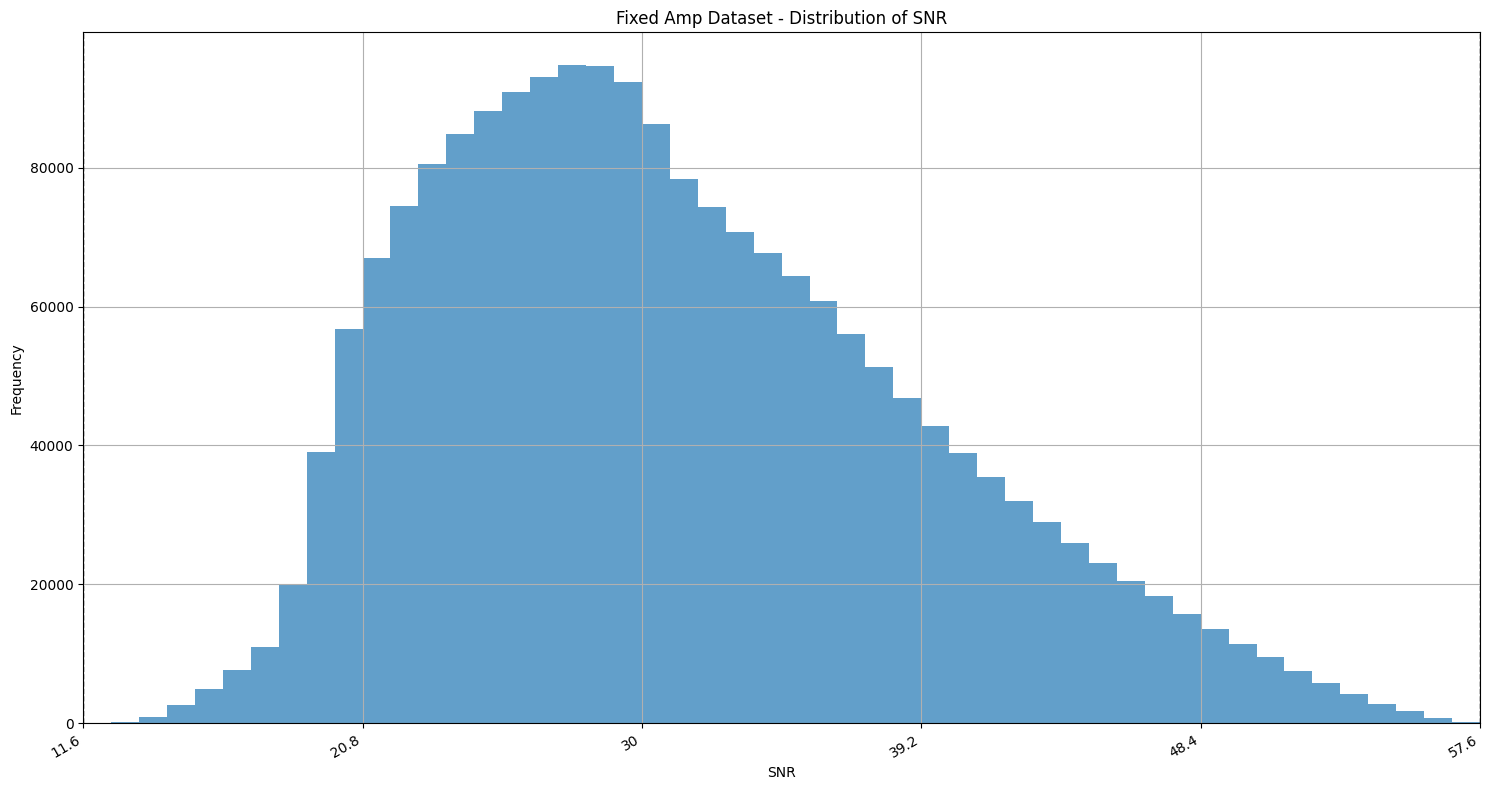

Min: 2.8183832353779204e-23, Max: 4.4668355767595083e-23, Mean: 3.579569953410693e-23, Std: 0.0


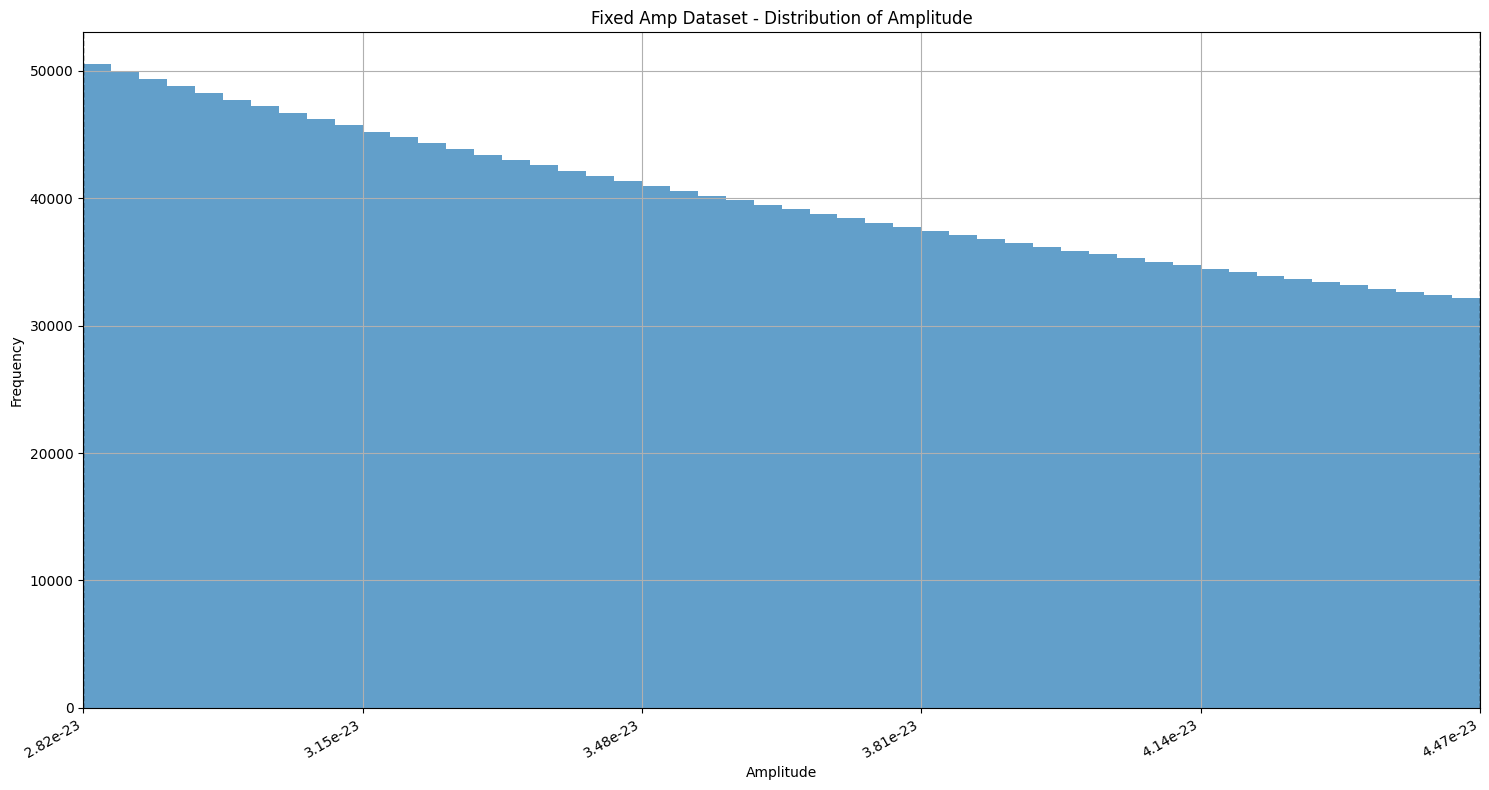

In [6]:
plot_histogram(params['snr'], "Fixed Amp Dataset - Distribution of SNR", "SNR", use_log=False)
plot_histogram(params['amp'], "Fixed Amp Dataset - Distribution of Amplitude", "Amplitude", use_log=False)

In [7]:
file_path = "../data/synthetic_dataset/dataset_1M_variable_amp.hdf5" # Keys : 'params', 'waveforms' 
params = {}
with h5py.File(file_path, "r") as f:
    waveforms = f["waveforms"][:]
    for key, value in f['params'].items():
        params[key] = value[:]

In [8]:
print(waveforms.shape)
print(params.keys())
print(params['f0'].shape)
print(params['snr'].shape)

(1048576, 4, 128)
dict_keys(['amp', 'beta', 'f0', 'fddot', 'fdot', 'iota', 'lam', 'phi0', 'psi', 'snr'])
(1048576,)
(1048576,)


Min: 2.1798202991485596, Max: 112.1786880493164, Mean: 31.25772476196289, Std: 27.172119140625


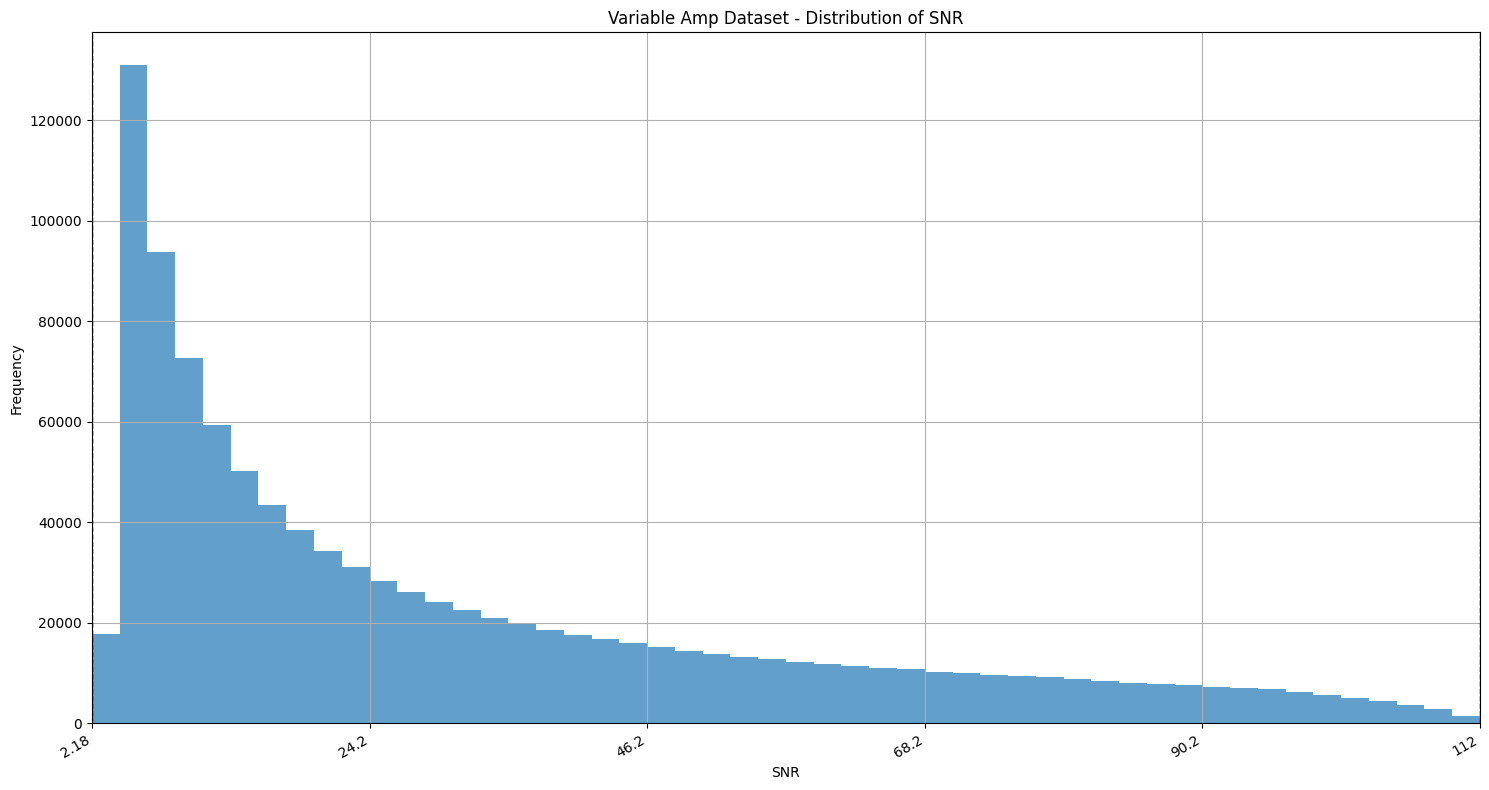

Min: 6.309587593426743e-24, Max: 1.5848890850824996e-22, Mean: 4.720773373138135e-23, Std: 3.743392066509216e-23


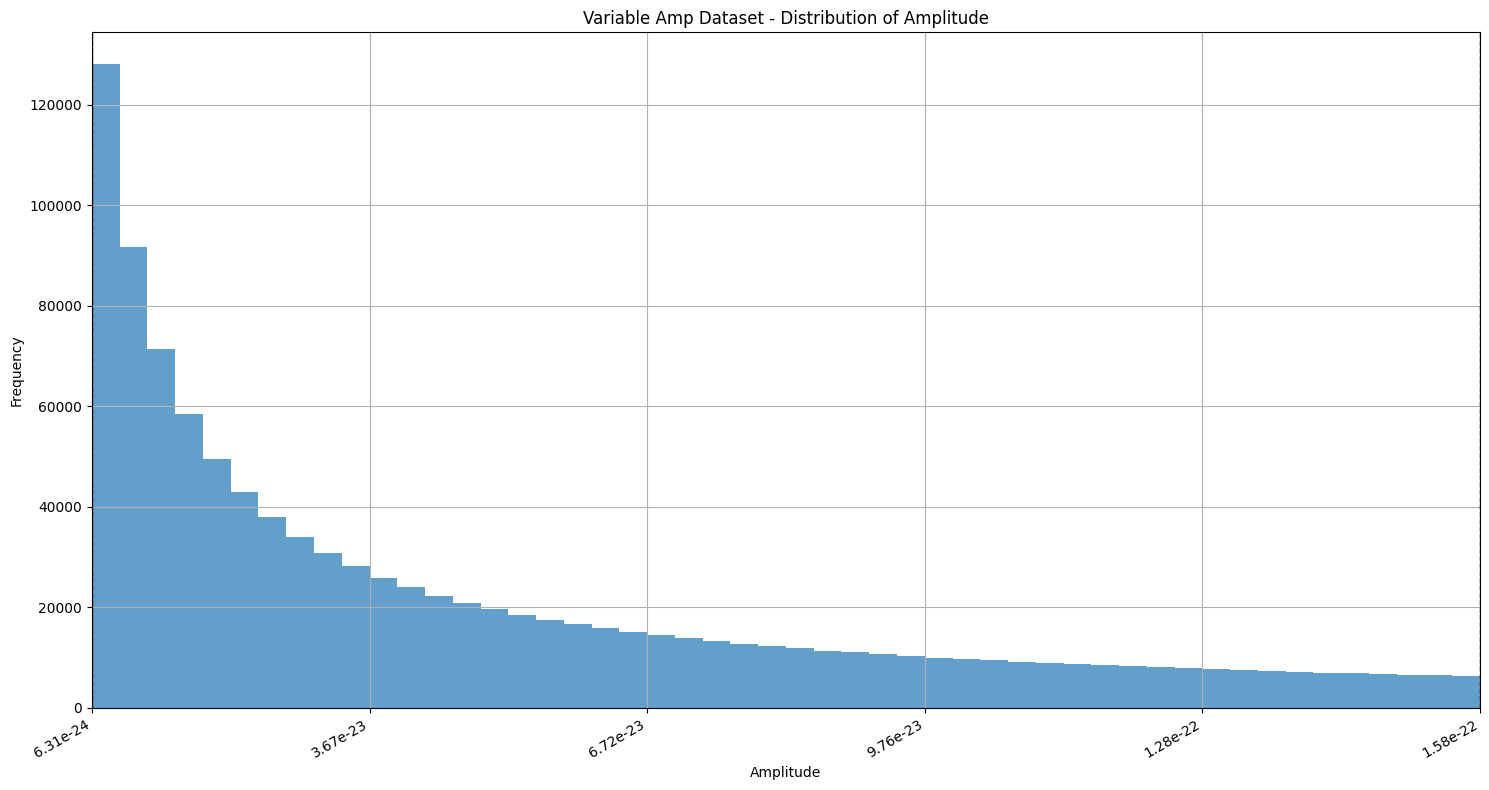

In [9]:
plot_histogram(params['snr'], "Variable Amp Dataset - Distribution of SNR", "SNR", use_log=False)
plot_histogram(params['amp'], "Variable Amp Dataset - Distribution of Amplitude", "Amplitude", use_log=False)

Min: 2.1798202991485596, Max: 112.1786880493164, Mean: 31.25772476196289, Std: 27.172119140625


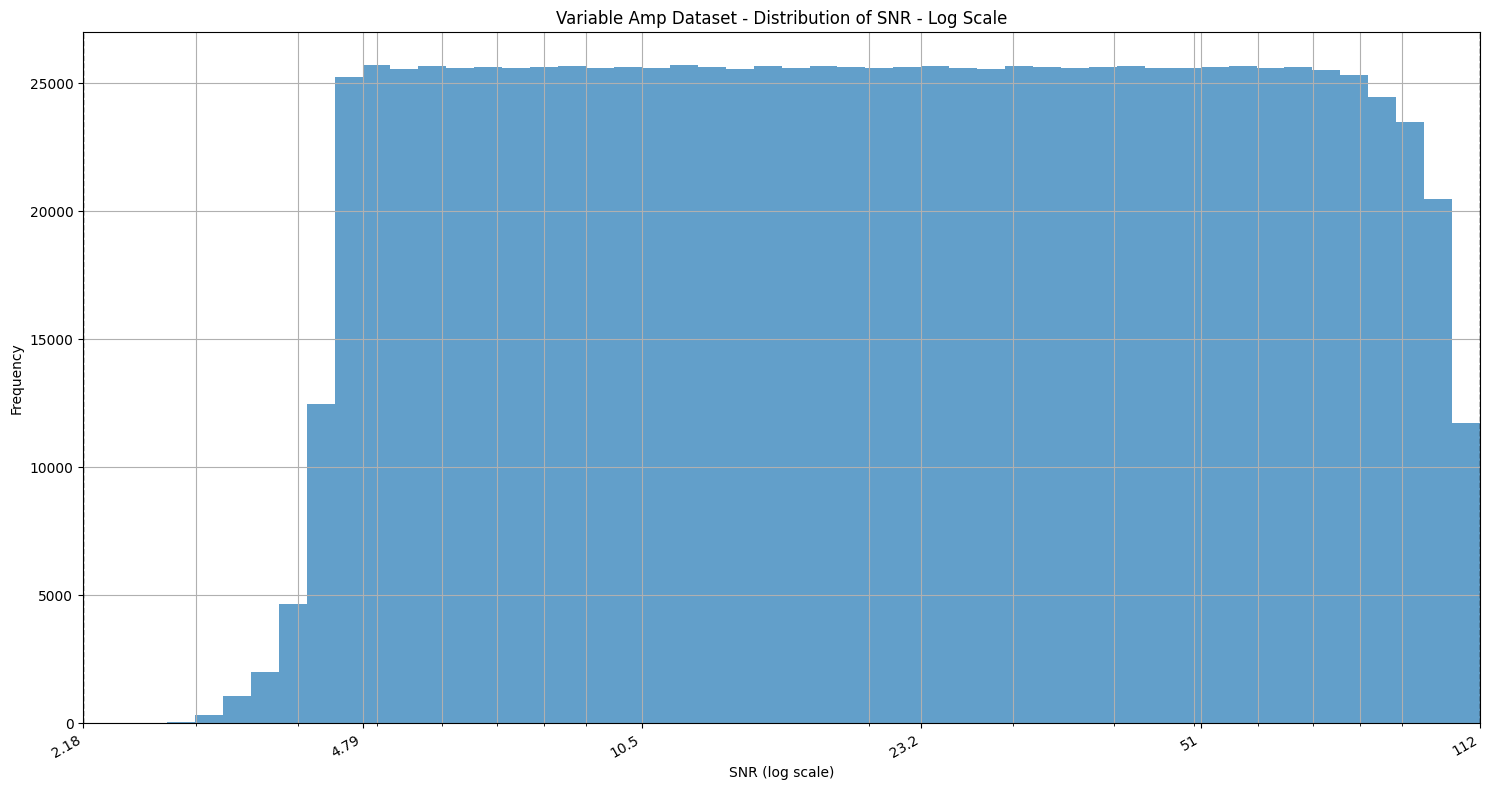

Min: 6.309587593426743e-24, Max: 1.5848890850824996e-22, Mean: 4.720773373138135e-23, Std: 3.743392066509216e-23


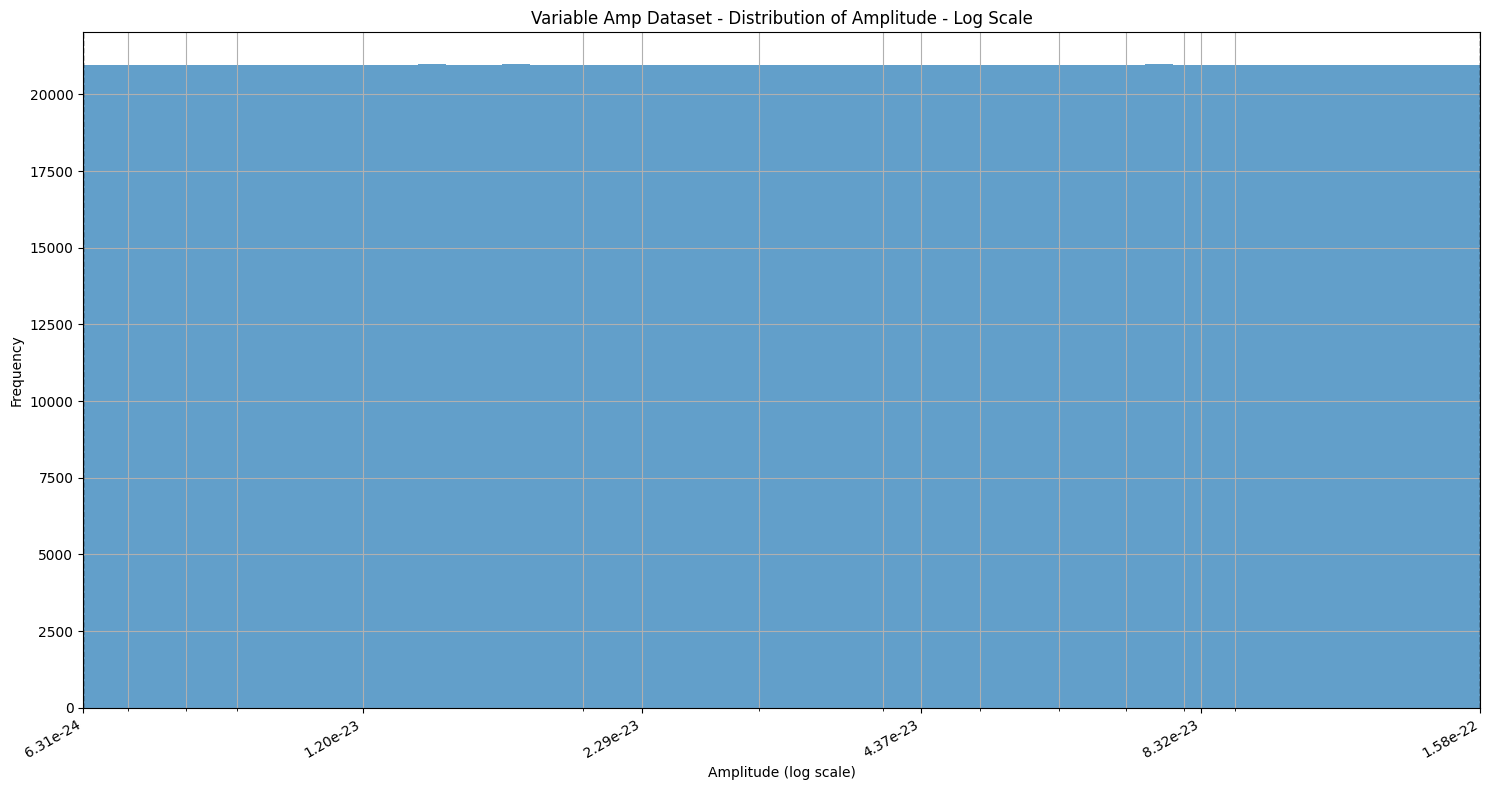

In [10]:
plot_histogram(params['snr'], "Variable Amp Dataset - Distribution of SNR - Log Scale", "SNR", use_log=True)
plot_histogram(params['amp'], "Variable Amp Dataset - Distribution of Amplitude - Log Scale", "Amplitude", use_log=True)